# 5-Choosability of Planar Graphs and <br>Packing Correspondence Colorings in $K_5$-Minor-free Graphs

## 1. Preliminaries

This notebook is designed to accompany the paper ''Disjoint Correspondence Colorings for $K_5$-Minor-free Graphs'' by Cames van Batenburg, Cranston, and Kardoš.  It is on arXiv at [https://arxiv.org/abs/2602.16692](https://arxiv.org/abs/2602.16692). Before introducing the relevant concepts, we begin with *list-coloring*.  A *k-assignment* gives to each vertex $v$ of a graph a list (a mathematical set) $L(v)$.  And a proper $L$-coloring $\varphi$ is a function $\varphi$ such that $\varphi(v)\in L(v)$ for all $v\in V(G)$ and $\varphi(v)\ne \varphi(w)$ whenever $vw\in E(G)$.  Thomassen famously proved the following.

**Theorem [Thomassen]**: If $G$ is a planar graph, then $G$ has a proper $L$-coloring for every 5-assignment $L$.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
from itertools import combinations, permutations
# import time
# from scipy.stats import linregress  # do we need this?
import sys
import random
rng = np.random.default_rng(123456)

We will want some graphs to test our algorithm on.  Of course, we can construct them deterministically, but it is convenient to be able to quickly generate planar graphs on an arbitrary number of vertices.  For coloring, adding edges makes the problem no easier, so we will typically consider graphs that are (nearly) edge-maximal in the relevant class.  But for planar graphs, it is much easier to draw the graph and make it look pretty if we only require that it is a *near* triangulation (the outer face might not be a triangle, but all other faces are).  For this purpose, Delaunay triangulations are a rich source of examples.

In [2]:
def random_planar_graph(n: int, d = 0, full = False, pos = False, verbose = False):
    # want to generate a delaunay triangulation on n points (in the unit square)
    # if d is provided, then we require that points are at pairwise distance at least d
    # we return the graph, and if d > 0, then we also return the vertex positions (to aid in drawing the graph)

    def vprint(my_fstring):
        if verbose == True:
            print(my_fstring)
            
    points = []
    if d == 0:
        points = rng.random((n, 2)) 
    else:  # recall that d is min allowable distance from all other earlier points
        # if we're careless we could try to fit in more points than possible; below is fairly conservative 
        assert n < 2 / (np.pi * d ** 2), f"Please decrease d to allow for {n} points."  # a factor of 2 over the density bound
        while len(points) < n:
            p = rng.random(2)
            if all(np.linalg.norm(p - q) >= d for q in points):
                points.append(p)
        
        points = np.array(points)
    
    tri = Delaunay(points)  # Delaunay is imported at the top of the notebook
    G = nx.Graph()                           
    G.add_nodes_from(range(n))     
    
    for face in tri.simplices.tolist():      # tolist() converts from dtype np.int32 (which is an np dtpye) to int (which is a python dtype)
        G.add_edges_from([                   # for each face add in its 3 incident edges
            (face[0], face[1]),
            (face[0], face[2]),
            (face[1], face[2])
        ])

    max_vert = n-1
    extra = 0
    if full:  # when full == True, we simply return G (without pos), regardless of whether or not pos == True
              # in short: full = True *overrides* pos = True
        # we want a full triangulation, so need to add a new vertex in the outer face and make it dominating
        # find 4^+-face f in embedding (assume G is near-triangulation, so only one such f exists)
        long_faces = []
        seen = set()  # so we don't re-traverse faces we've already seen 
        is_planar, embedding = nx.check_planarity(G)
        assert is_planar
        
        for v, w in embedding.edges:
            if (v, w) not in seen:
                temp = embedding.traverse_face(v, w, mark_half_edges=seen)
                if len(temp) >= 4:
                    long_faces.append(temp)

        for face in long_faces:
            extra += 1
            new_vert = max_vert + extra
            G.add_node(new_vert)
            for vert in face:
                G.add_edge(vert, new_vert)
        vprint(f"Added {extra} extra vertices to reach a full triangulation.")
        is_planar, embedding = nx.check_planarity(G)
        vprint(f"Order of G is {len(G)} and size of G is {len(G.edges())}.")
        return G
    if pos == False:
        return G
    else:
        pos = {}                        
        for v in range(len(points)):
            pos[v] = points[v]          # convert the point coordinates from an array into a dictionary
    
        return G, pos

In [3]:
D200 = random_planar_graph(200, 0)

The option ```full = True``` enforces that the graph be a *maximal* planar graph, which will be helpful later.  To ensure this, we simply
add a new vertex in the interior of each $4^+$-face $f$ and make it adjacent to all vertices on $f$.  (In this case, the order might be slightly larger than requested.) This "fullness" can be verified by checking that ```len(G.edges) = 3 * len(G) - 6```

In [4]:
D300 = random_planar_graph(300, 0, full = True, verbose=True)

Added 1 extra vertices to reach a full triangulation.
Order of G is 301 and size of G is 897.


And the ```pos = True``` option is useful for later actually drawing the graph.

In [5]:
D200, D200pos = random_planar_graph(200, 0.05, pos = True)

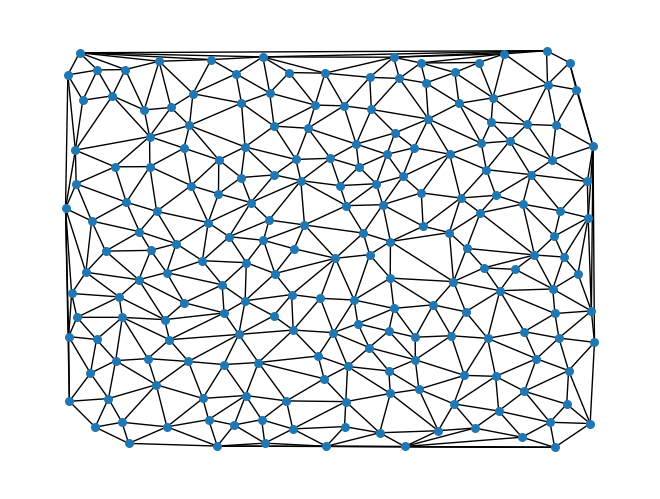

In [6]:
nx.draw(D200, pos = D200pos, node_size = 30)

## 2. 5-Choosability of Planar Graphs

### 2.1 The Code

The proof of Thomassen's 5-choosability result relies on a strengthened induction hypothesis.  Two adjacent vertices, $v_1$ and $v_2$, on the boundary cycle of the outer face are precolored (they have distinct lists of size 1) and the other vertices on the boundary cycle $C$ each have a list of size 3.  For the induction step we split on whether or not $v_n$, the neighbor of $v_1$ on $C$ (other than $v_2$), has an incident chord $e$ of the boundary cycle.  When it does, we recurse first on one side of $C+e$ and then on the other.  When no such chord exists, we can delete $v_n$ from the boundary cycle, adding instead a path through its neighbors (and decreasing by 2 the list for each such neighbor).  We then color $v_n$ after this recursive call finishes.
This is all reflected in the code below.

Most of the work of the function is done by a recursive function ```t_recurse```, and the first call to ```t_recurse``` is prepared by a wrapper function ```thomassen_coloring```.  One nice feature of ```t_recurse``` is that it need not be passed as input $G$, the plane embedding, or the lists; all of these are inherited from ```thomassen_coloring```.  All that is passed to ```t_recurse``` is a list of the vertices of the current boundary cycle.  An interesting feature of the algorithm is that that neither $G$ nor the embedding ever changes; we just recurse on various induced subgraphs.  Only the lists are mutated.  This property gives rise to a nice visualization of the algorithm, which we will see later.  To drive the visualization, we need to store and return some extra information.  This is done with the keyword argument ```animations = True```.  We also have the option to pass into ```thomassen_coloring``` a plane embedding using ```embedding = embedding```.  This can save significant time for large graphs and helps isolate the time spent running the coloring algorithm, rather than simply computing a plane embedding.  Finally, there is an optional argument ```DEBUG = True```, which gives a bit more information about the lengths of the (outer) cycles for our recursive calls.  This information is particularly relevant when combined with ```animations = True```.

In [7]:
def thomassen_coloring(G: nx.Graph, lists0: dict, animations = False, embedding = None, DEBUG = False):  # wrapper, preparing to recurse
    lists = {v: L.copy() for v, L in lists0.items()}   # to protect the input, since alg below will restrict the lists   
    assert all(len(L) >= 5 for v, L in lists.items())  # check that each list has size at least 5

    if embedding is None:  
        is_planar, embedding = nx.check_planarity(G)
        assert is_planar
    else:  # option to provide embedding, to save the time of computing it ourselves
        print("Using embedding provided (without verifying that it is valid).")
        
    if animations:
        cycle_list = []  # for the animations
    
    calls = 0
    total_C_length = max_C_length = 0

    def t_recurse(C: list) -> None:  # this (recursive) function does most of the work 
        nonlocal lists
        if DEBUG:
            nonlocal calls, total_C_length, max_C_length
            calls += 1
            total_C_length += len(C)
            max_C_length = max(len(C), max_C_length)
        
        C_short = len(C) == 3  # C is short
        if C_short:
            v1, v2, v3 = C
            
        if C_short and set(embedding.traverse_face(v1, v2)) == {v1, v2, v3}:  # and C also has no verts in its interior  
            # base case of recursion; get color for v3 and return
            lists[v3].difference_update(lists[v1] | lists[v2])  # discard from L(v3) both L(v1) and L(v2)
            lists[v3] = {lists[v3].pop()}  # actually pick a single color for v3
            if animations:
                cycle_list.append((C,[],[],[v3]))
            return
                
        else:
            # check for chords incident with vn; if such a chord exists (could be many), pick an arbitrary one; call its other endpoint vi
            vnm1, vn = C[-2:]
            v1 = C[0]
            chords = (set(C) & set(G.neighbors(vn))) - {v1, vnm1}
            vi = chords.pop() if chords else None
                               
        
            if vi is None:  # chord does not exist:
                x = embedding.traverse_face(vn,v1)[2]
                # use traverse_neighbors_cw(vn) and x to find P and update C (call it Cnew)
                nbr_cycle = list(embedding.neighbors_cw_order(vn))
                nbr_cycle = nbr_cycle if nbr_cycle.index(x) == ((nbr_cycle.index(v1)+1)%len(nbr_cycle)) else list(reversed(nbr_cycle))
                assert nbr_cycle.index(x) == ((nbr_cycle.index(v1)+1)%len(nbr_cycle))  # check that nbr_cycle looks like we want it to
                a = nbr_cycle.index(v1)
                b = nbr_cycle.index(vnm1)
                # get the (directed) path of nbr_cycle running from v1 to vnm1, excluding both vertices
                P = nbr_cycle[a+1:b] if b > a else nbr_cycle[a+1:] + nbr_cycle[0:b]
                Cnew = C[:-1] + list(reversed(P))
        
                # pick 2 safe colors {c1, c2} for vn
                lists[vn].difference_update(lists[v1])
                c1 = lists[vn].pop()
                c2 = lists[vn].pop()
                safe = {c1, c2}
                lists[vn] = safe
                # remove c1, c2 from L(w) for all w in P\setminus {v1, v{n-1}}
                for w in P:
                    lists[w].difference_update(safe)
        
                if animations:
                    cycle_list.append((Cnew,[v for v in P],[vn],[]))
                t_recurse(Cnew)
                
                # color vn from {c1,c2} \setminus L(vnm1)
                lists[vn].difference_update(lists[vnm1])
                lists[vn] = {lists[vn].pop()}  # actually choose a color for vn
                if animations:
                    cycle_list.append((Cnew,[],[],[vn]))
                if animations:
                    cycle_list.append((C,[],[],[]))
        
            else:  # chord exists
                i = C.index(vi)
                C1 = C[:i+1] + [vn]
                C2 = [vn] + C[i:-1]
        
                if animations:
                    cycle_list.append((C1,[],[],[]))
                t_recurse(C1)
                if animations:
                    cycle_list.append((C,[],[],[]))
            
                if animations:
                    cycle_list.append((C2,[],[],[]))
                t_recurse(C2)
                if animations:
                    cycle_list.append((C,[],[],[]))

    # find 4^+-face f in embedding (assume G is near-triangulation, so only one such f exists)
    long_faces = []
    seen = set()  # so we don't re-traverse faces we've already seen 
    
    for v, w in embedding.edges:
        if (v, w) not in seen:
            temp = embedding.traverse_face(v, w, mark_half_edges=seen)
            if len(temp) >= 4:
                long_faces.append(temp)
                
    assert len(long_faces) <= 1
    v, w = next(iter(embedding.edges))
    C = long_faces[0] if long_faces else embedding.traverse_face(v, w)
    
    # get directed boundary cycle \vec{C} of f, with G (all but the outer face) on the *right* of \vec{C}
    C = list(reversed(C))  # want the outer face (f) on the *left* of C, not the right
    # specify v1, v2 as first on \vec{C}
    v1 = C[0]
    v2 = C[1]
    
    # reduce lists for v1, v2 (don't touch other lists)
    lists[v1] = {lists[v1].pop()}                # restrict L(v1) to a singleton
    lists[v2].difference_update(lists[v1])       # remove L(v1), now a singleton, from L(v2)
    lists[v2] = {lists[v2].pop()}                # restrict L(v2) to a singleton

    if animations:
        cycle_list.append((C,[v for v in C if v not in {v1, v2}],[],[v1,v2]))
    t_recurse(C)

    coloring = {v: L.pop() for v, L in lists.items()}  # convert (singleton) lists to dictionary of coloring
    assert all(coloring[v] in lists0[v] for v in G.nodes)  # double check that every vertex is really colored from *its* list
    if DEBUG:
        print(f"Total calls is {calls}.")
        print(f"total_C_length is {total_C_length} and max_C_length is {max_C_length}.")
    if animations:
        return coloring, cycle_list
    else:
        return coloring

### 2.2 Examples of 5-Choosability of Planar Graphs

In this section, we draw some graphs along with their coloring resulting from ```thomassen_coloring```.  The following two helper function ```all_fives(G)``` and ```random_fives(G)``` are useful for creating 5-assignments (list assignments with each list of size 5) for an arbitrary input graph.  The first gives every vertex the list $\{0,1,2,3,4\}$ while the second picks independently for each vertex a 5-element subset of $\{0,1,2,3,4,5,6,7,8,9\}$.

In [8]:
def all_fives(G): 
    return {v: {1,2,3,4,5} for v in G}
palette = set(range(10))
list_of_5lists  = list(combinations(palette, 5))
def random_fives(G): 
    return {v: set(random.choice(list_of_5lists)) for v in G}

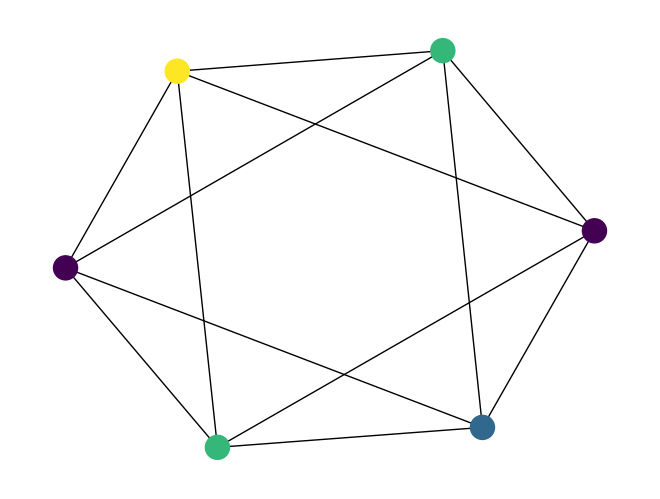

In [9]:
octa = nx.octahedral_graph()
octa_all_fives = all_fives(octa)
octa_colors = thomassen_coloring(octa, octa_all_fives)
nx.draw(octa, pos=nx.spring_layout(octa, seed=2), node_color = [octa_colors[v] for v in octa])

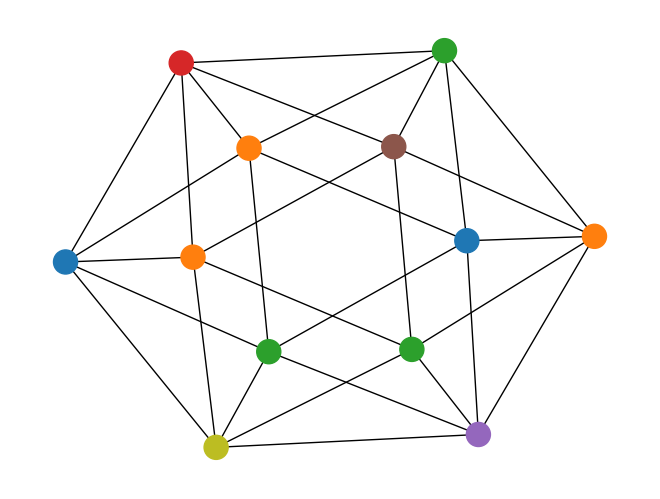

In [10]:
icos = nx.icosahedral_graph()
icos_random_fives = random_fives(icos)
icos_colors = thomassen_coloring(icos, icos_random_fives)
nx.draw(icos, pos=nx.spring_layout(icos, seed=7), node_color = [icos_colors[v] for v in icos], cmap=plt.cm.tab10, vmin=0, vmax=9)

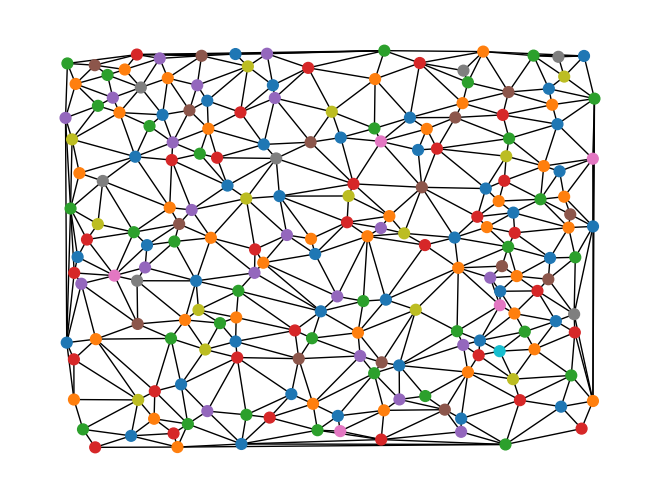

In [11]:
n = 200
d = 0.03
G200, G200_pos = random_planar_graph(n,d, pos = True)
G200_random_fives = random_fives(G200)
G200_colors = thomassen_coloring(G200, G200_random_fives)
nx.draw(G200, pos=G200_pos, node_color = [G200_colors[v] for v in G200], node_size = 60, cmap=plt.cm.tab10)

In the example above, there is nothing special about the number 200.  Feel free to change it and rerun the cell.  The only potential issue is that if you increase $n$ too much, say above 700, you will need to decrease $d$ to ensure that we can fit enough (random) points in the unit square, pairwise at distance at least $d$.

Below is a bigger example (that becomes a bit hard to see).

In [12]:
G2000, G2000_pos = random_planar_graph(2000,.001, pos = True)
G2000_random_fives = random_fives(G2000)

In [13]:
G2000_colors = thomassen_coloring(G2000, G2000_random_fives, DEBUG = True)

Total calls is 2978.
total_C_length is 169289 and max_C_length is 197.


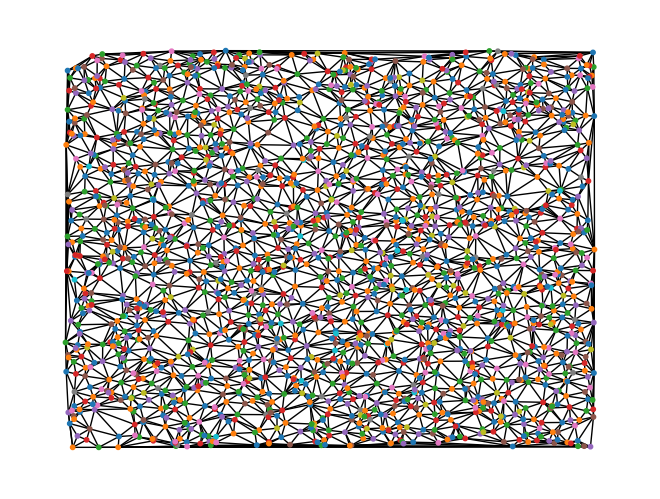

In [14]:
nx.draw(G2000, G2000_pos, node_color = [G2000_colors[v] for v in G2000], node_size = 10, cmap=plt.cm.tab10)

In [15]:
G200000 = random_planar_graph(200000)
G200000_random_fives = random_fives(G200000)

If we consider a graph that is *much* larger, as above, the main cost in time is computing a plane embedding.  (Note that we omitted the optional argument ```d```, so we are not enforcing any minimum distance between the points.)

In [16]:
is_planar, embedding = nx.check_planarity(G200000)

The function ```thomassen_coloring``` is *recursive*, so to call it on a much larger graph, we need to increase the recursion depth.
(A safe threshold is typically anything more than twice the order of the graph.)

In [17]:
sys.setrecursionlimit(500000)

In [18]:
G200000_colors = thomassen_coloring(G200000, G200000_random_fives, embedding = embedding, DEBUG = True)

Using embedding provided (without verifying that it is valid).
Total calls is 297759.
total_C_length is 193494741 and max_C_length is 2360.


### 2.3 Visualizing the 5-Choosability Algorithm

In this section we *visualize* the coloring algorithm above.  The following (animation) function is primarily javascript, along with a bit of python and a bit of css.

In [19]:
import json
from IPython.display import IFrame, display

def animate_cycles_html(G, pos, cycles, filename=None, width=700, height=700):

    # Visual parameters.
    color1 = "#145a32"
    color2 = "#4f9a68"
    color3 = "#b7d9c0"
    face_shade = "#eeeeee"
    cycle_color = "#d94801" # "#d95f02" # "#dc6601" #"#ff8c00" #"#ff991c" # previously, "red"
    highlight_color = "#ffd700"
    vertex_size = 7
    cycle_width = 5
    base_interval = 500

    if filename is None:
        filename = "cycle-animation.html"

    vertices = list(G)
    vertex_index = {v: i for i, v in enumerate(vertices)}

    gray_at = [None] * len(vertices)
    dgray_at = [None] * len(vertices)
    black_at = [None] * len(vertices)
    changed = [[] for _ in cycles]

    for i, (_, gray, dgray, black) in enumerate(cycles):
        for v in gray:
            gray_at[vertex_index[v]] = i
            changed[i].append(vertex_index[v])
        for v in dgray:
            dgray_at[vertex_index[v]] = i
            changed[i].append(vertex_index[v])
        for v in black:
            black_at[vertex_index[v]] = i
            changed[i].append(vertex_index[v])

    color_change_frames = [i for i, c in enumerate(changed) if c]

    # Find triangular faces and when they become processed.
    is_planar, embedding = nx.check_planarity(G)
    assert is_planar

    faces = []
    seen = set()
    for u, v in embedding.edges:
        if (u, v) not in seen:
            face = embedding.traverse_face(u, v, mark_half_edges=seen)
            if len(face) == 3:
                faces.append(face)

    processed_at = [
        max(black_at[vertex_index[v]] for v in face)
        if all(black_at[vertex_index[v]] is not None for v in face)
        else None
        for face in faces
    ]

    xs = [pos[v][0] for v in vertices]
    ys = [pos[v][1] for v in vertices]
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)
    margin = 30

    def point(v):
        return (
            margin + (pos[v][0] - xmin) / (xmax - xmin) * (width - 2 * margin),
            height - margin
            - (pos[v][1] - ymin) / (ymax - ymin) * (height - 2 * margin)
        )

    face_polygons = "\n".join(
        f'<polygon class="face" points="{" ".join(f"{point(v)[0]},{point(v)[1]}" for v in face)}"/>'
        for face in faces
    )

    edges = "\n".join(
        f'<line x1="{point(u)[0]}" y1="{point(u)[1]}" '
        f'x2="{point(v)[0]}" y2="{point(v)[1]}"/>'
        for u, v in G.edges
    )

    nodes = "\n".join(
        f'<circle class="vertex" data-index="{i}" '
        f'cx="{point(v)[0]}" cy="{point(v)[1]}" r="{vertex_size}"/>'
        for i, v in enumerate(vertices)
    )

    cycle_points = [
        " ".join(f"{point(v)[0]},{point(v)[1]}" for v in C + [C[0]])
        for C, _, _, _ in cycles
    ]

    html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<style>
body {{ font-family:sans-serif; text-align:center; }}
svg {{ border:1px solid #ccc; }}
.controls {{ display:flex; flex-wrap:wrap; justify-content:center;
             align-items:center; gap:8px 18px; }}
.group {{ display:flex; align-items:center; white-space:nowrap; }}
button,select {{ font-size:16px; margin:5px; padding:5px 12px; }}
input[type=range] {{ width:300px; margin:5px 10px; }}
.status {{ margin-left:20px; }}
</style>
</head>
<body>

<div class="controls">

<div class="group">
<button id="prev">Previous</button>
<button id="play">Play</button>
<button id="next">Next</button>
<select id="speed">
<option value=".5">0.5×</option>
<option value="1" selected>1×</option>
<option value="2">2×</option>
<option value="4">4×</option>
<option value="8">8×</option>
</select>
<label><input type="checkbox" id="colorOnly">
Only show color changes</label>
</div>

<div class="group">
<input type="range" id="slider" min="0" max="{len(cycles)-1}" value="0">
<span id="label"></span>
<span class="status" id="status"></span>
</div>

</div>

<svg width="{width}" height="{height}" viewBox="0 0 {width} {height}">
<g fill="{face_shade}" stroke="none">{face_polygons}</g>
<g stroke="black" stroke-width="1" fill="none">{edges}</g>
<polyline id="cycle" fill="none"
          stroke="{cycle_color}" stroke-width="{cycle_width}"/>
<g stroke="black">{nodes}</g>
</svg>

<script>
const cycles={json.dumps(cycle_points)};
const grayAt={json.dumps(gray_at)};
const dgrayAt={json.dumps(dgray_at)};
const blackAt={json.dumps(black_at)};
const changed={json.dumps(changed)};
const colorChangeFrames={json.dumps(color_change_frames)};
const processedAt={json.dumps(processed_at)};
const color1="{color1}", color2="{color2}", color3="{color3}";
const faceShade="{face_shade}", highlight="{highlight_color}";
const baseInterval={base_interval};

let current=0, playing=false, timer=null, colorOnly=false;

const cycle=document.getElementById("cycle");
const slider=document.getElementById("slider");
const label=document.getElementById("label");
const status=document.getElementById("status");
const speed=document.getElementById("speed");
const colorOnlyBox=document.getElementById("colorOnly");
const vertices=document.querySelectorAll(".vertex");
const faces=document.querySelectorAll(".face");

function frames() {{
    return colorOnly ? colorChangeFrames : cycles.map((_,i)=>i);
}}

function show(i) {{
    const f=frames();
    current=(i+f.length)%f.length;
    const frame=f[current];

    cycle.setAttribute("points",cycles[frame]);
    slider.value=current;
    label.textContent=`Cycle ${{frame+1}} / ${{cycles.length}}`;

    vertices.forEach((v,j) => {{
        v.setAttribute("fill",
            blackAt[j] !== null && blackAt[j] <= frame ? color1 :
            dgrayAt[j] !== null && dgrayAt[j] <= frame ? color2 :
            grayAt[j] !== null && grayAt[j] <= frame ? color3 : "white");

        const h=changed[frame].includes(j);
        v.setAttribute("stroke",h ? highlight : "black");
        v.setAttribute("stroke-width",h ? 3 : 1);
    }});

    faces.forEach((face,j) =>
        face.setAttribute("fill",
            processedAt[j] !== null && processedAt[j] <= frame
                ? faceShade : "none"));

    status.textContent =
        `Vertices colored ${{blackAt.filter(t => t !== null && t <= frame).length}} / ${{vertices.length}}`;
}}

function restart() {{
    if (timer) clearInterval(timer);
    if (playing)
        timer=setInterval(() => show(current+1),
                          baseInterval/Number(speed.value));
}}

prev.onclick=()=>show(current-1);
next.onclick=()=>show(current+1);
slider.oninput=()=>show(Number(slider.value));

play.onclick=()=>{{
    playing=!playing;
    play.textContent=playing ? "Pause" : "Play";
    restart();
}};

speed.onchange=restart;

colorOnlyBox.onchange=()=>{{
    const frame=frames()[current];
    colorOnly=colorOnlyBox.checked;
    const f=frames();
    slider.max=f.length-1;
    let i=f.indexOf(frame);
    if (i < 0) {{
        i=f.findIndex(x=>x>frame);
        if (i < 0) i=f.length-1;
    }}
    show(i);
}};

show(0);
</script>

</body>
</html>
"""

    with open(filename, "w") as f:
        f.write(html)

    return filename

To make use of the previous function, we need to record more information about the run of our algorithm.  We do this with the keyword argument ```animations = True```.  Now the function returns an additional list that encodes the information we need to pass to the function above ```animate_cycles_html```.  In the proof, vertices $v_1,v_2$ each have lists of size 1, the other vertices on the boundary of the outer face have lists of size 3, and all ``untouched'' vertices have lists of size 5.  However, there is another case that arise during one of the recursive calls (when $v_n$ has no incident chord of the boundary cycle) where a vertex has a list of size 2.  In the animation below, we do not focus on the actual color choosen for each vertex but rather only on the size of the list for that vertex.  Lists of size 5, 3, 2, 1 are denoted by colors white, light green, green, and dark green.  (Colors get darker as list sizes decrease.)  In the visualization, we also shade each triangular face once all 3 of its incident vertices has been colored.  This helps to quickly show which parts of the graph are finished, and which will be returned to later.

We start with the icosahedron, and then consider some larger plane near triangulations.

In [20]:
icos = nx.icosahedral_graph()
isplanar, icos_embedding = nx.check_planarity(icos)
icos_random_fives = random_fives(icos)
icos_colors, icos_update_list = thomassen_coloring(icos, icos_random_fives, animations = True)
icos_pos = nx.combinatorial_embedding_to_pos(icos_embedding)

In [21]:
filename_icos = animate_cycles_html(icos, icos_pos, icos_update_list, width=640, height=540)
display(IFrame(filename_icos, width=820, height=680))

Next we try a slightly larger graph.

In [22]:
G30, G30_pos = random_planar_graph(30, .1, pos = True)
G30_random_fives = random_fives(G30)
G30_colors, G30_update_list = thomassen_coloring(G30, G30_random_fives, animations = True)

In [23]:
filename30 = animate_cycles_html(G30, G30_pos, G30_update_list, width=640, height=540)
display(IFrame(filename30, width=820, height=680))

In [24]:
G200_colors, G200_update_list = thomassen_coloring(G200, G200_random_fives, animations = True)

For larger graphs, it is often useful to switch the playback speed to ```4x``` or ```8x```.  Then, if you want to investigate some part of the process more closely, you can pause and investigate with ```Previous``` and ```Next```.  Each time that a vertex changes color, that event is highlighted with a yellow ring.  This does not happen at each step, since at some points the boundary cycle is simply shifting.  If you want to only see the steps when a vertex changes color, you can enforce that with the checkbox.

In [25]:
filename200 = animate_cycles_html(G200, G200_pos, G200_update_list, width=640, height=540)
display(IFrame(filename200, width=820, height=680))

## 3. Correspondence Coloring and Correspondence Packing

### 3.1 Overview of Main Functions and their Code

We finally come to correspondence coloring.  In a sense, it is intuitively "like list-coloring", but more general.  Each vertex gets a list of $k$ colors, denoted mathematically by $\{1,\ldots,k\}$, but in the code by ```set(range(k))```.  And each edge $vw$ of the graph is given a matching between the copy of $\{1,\ldots,k\}$ corresponding to $v$ and the copy corresponding to $w$.  A correspondence coloring $\varphi$ assigns to each vertex a color from its list so that no adjacent vertices are assigned colors that are matched to each other.
In code, this means ```assert all(coloring[v] in range(k) for v in G)``` and ```assert all(matching[v,w][coloring[v]] != coloring[w] for v1,v2 in G.edges for v,w in {(v1,v2), (v2,v1)})```.

*Correspondence $s$-packing* means that we want to find $s$ "disjoint" correspondence colorings $\varphi_1,\ldots,\varphi_s$ such that each $\varphi_i$ is a correspondence coloring.  (Here *disjoint* means that $\varphi_i(v) \ne \varphi_j(v)$ for all $v\in V(G)$ and distinct $i,j\in [k]$.)  In our case, we have $s=3$, so we are looking for disjoint correspondence colorings $\varphi_1, \varphi_2, \varphi_3$.  To formally state the main result of the paper, we need one more definition.  A *$k$-cover* $\mathbf{M}$ of a graph $G$ assigns to each vertex the set (of "colors") $\{1,\ldots,k\}$ and to each edge $vw$ of $G$ a matching.  So $\mathbf{M}$ denotes this collection of matchings.

**Main Theorem**: Let $G$ be a $K_5$-minor-free graph. For every correspondence 6-cover $\mathbf{M}$ of $G$,
there exist 3 disjoint $\mathbf{M}$-colorings $\varphi_1, \varphi_2, \varphi_3$. That is, for all $v\in V(G)$ the colors $\varphi_1(v), \varphi_2(v), \varphi_3(v)$ are pairwise distinct.

The core ideas in the proof of the Main Theorem are very similar to those in those of Thomassen's 5-choosability proof for planar graphs.
For this to make sense, we need the following definitions and theorem.  A *$b$-clique sum* of two graphs $G_1$ and $G_2$ is formed from their disjoint union by specifying ordered vertex sets $\{v_1,\ldots,v_b\}$ and $\{w_1,\ldots,w_b\}$, with $v_i \in V(G_1)$ and $w_i \in V(G_2)$ for all $i\in[b]$, and identifying $v_i$ and $w_i$ for all $i\in[b]$.  (This definition is slightly more simplified than is typical, but will suffice for our needs here.)  The *Wagner* graph, denoted $W_8$, is formed from the 8-cycle by adding edges between the 4 pairs of vertices at distance 4 on the cycle.  Wagner proved the following.

**Wagner's Theorem**:  A graph is edge-maximally $K_5$-minor-free if it can be formed from maximal planar graphs and copies of $W_8$ by repeated $2$-clique sums and $3$-clique sums.

So the outline of the proof of the Main Theorem is to prove it for maximal planar graphs and to prove it for copies of the Wagner graph, and somehow to "paste together" the results for these various pieces.  The key point for planar graphs is that we can copy the main idea from Thomassen's 5-Choosability result.  But, as we mentioned above, the proof uses a strengthened induction hypothesis that actually allows us to "precolor" two adjacent vertices.  This precoloring strengthening is exactly what we need to make the colorings match on 2 planar pieces that are pasted together via a 2-clique sum.  And by pushing this idea a bit farther we can also use it to handle 3-clique sums.  And the copies of $W_8$ are easy to handle because each copy has only 8 vertices and each vertex has only degree 3 in its copy.

Before saying any more about the mathematics, let's look at the key functions and discuss how they interact.

```python 
def pack3_K5minorfree_corr(G: nx.Graph, matchings: dict, pieces: list[set]):
def pack3_planar_corr(G, C = None):  # defined within pack3_K5minorfree_corr; inherits access to matchings and lists
def pack3_planar(C):  # defined within pack3_planar_corr; inherits access to matchings and lists and embedding
def pack3_wagner_corr(G, colored_verts = None):  # defined in pack3_K5minorfree_corr; gets access to matchings & lists
def extend_3pack_corr(v):  # needs access to G, matchings, lists; only used by pack3_wagner_corr, so defined there
```

```pack3_K5minorfree_corr``` is the main wrapper function, and the only function above that is public.  Its first arguments are a graph $G$ and a set of matchings $\mathbf{M}$, one for every edge of $G$.  Each matching is from $[6]$ to $[6]$; we typically assume that each matching is perfect (has size 6), since doing so makes the problem no easier.  Finally ```pieces``` is a list of vertex subsets encoding the decomposition via 2-clique sums and 3-clique sums; we require that each piece induce either a copy of $W_8$ or a maximal planar graph (on at least 4 vertices).  We do not make any effort to compute such a decomposition, which is a different problem, but assume that a valid one is given.

Each planar piece is handled by ```pack3_planar_corr```, with most of the work being passed recursively to ```pack3_planar(C)```.  The processing of each planar piece closely mirrors that done in the previous section, when we constructed list-colorings of planar graphs; so $C$ is the (ever-evolving) outer cycle in the current recursive call.  The visualization of how we handle a planar piece is identical to that from the previous section, so we do not reproduce it here.

Each copy of $W_8$ is handled by ```pack3_wagner_corr```.  A simple counting argument (and Hall's Theorem) shows that we can easily extend a 3-packing to a vertex $v$ with at most 3 colored neighbors; this is implemented in ```extend_3pack_corr(v)```.  So when we get to a new copy of $W_8$, we simply extend (in succession) to each of its uncolored vertices, in an arbitrary order.  For each copy of $W_8$ that is not the first piece, we will inherit (from some previous piece) 2 vertices that are already precolored; these can be passed with the optional argument ```colored_verts```, so that we do not try to color them again.

Similarly, for each planar piece after the first, either 2 or 3 of its vertices (inducing a clique) will already be colored, from a previous piece.  We do not need to specify these explicitly; they are implicit in our specification of $C$ the boundary of the outer cycle.
If just 2 vertices are precolored, this is exactly what is allowed by the strengthened induction hypothesis, and these play the roles of $v_1, v_2$ on $C$.  In the case that 3 vertices are precolored, we need a small trick (essentially deleting $v_3$ and building a longer cycle $C$ that begins with $v_1,v_2$ and then continues through neighbors of $v_3$ in the plane embedding).

Now, without further ado, here is the code.

In [26]:
def pack3_K5minorfree_corr(G: nx.Graph, matchings0: dict, pieces: list[set], verbose = False):
    # takes a maximal K5-minor-free graph, along with a dictionary of a matching for each (directed) edge, and a list (pieces)
    # of vertex subsets each of which induces either a maximal planar graph or a copy of W_8 such that each piece (after the first)
    # has its intersection with the union of all earlier pieces contained in a single piece, and that intersection induces K_2 or K_3; 
    # further, if that intersection induces K_3, then that piece has a plane embedding where that K_3 is a face boundary (not a separating 
    # K_3) if verbose is True, print some short diagnostics about which pieces are planar or Wagner and which were colored successfully

    def vprint(my_fstring):
        if verbose:
            print(my_fstring)
        
    start = {0, 1, 2, 3, 4, 5}  # the 6 available colors for each vertex
    lists = {v: [start.copy(), start.copy(), start.copy()] for v in G.nodes}  # make "candidate sets" for each coloring, for each vertex
    perms3 = tuple(permutations(range(6),3))  # we will want perms3 and perms6 multiple times, so just compute them each once now
    perms6 = tuple(permutations(range(6)))
    wagner = nx.cycle_graph(8); wagner.add_edges_from({(i, i+4) for i in range(4)})
   
    # check that the matchings for oppositely directed edges really are inverses
    matchings = {} 
    for v,w in G.edges:  # G.edges is *undirected*, but matchings is *directed*
        matchings[v,w] = matchings0[v,w].copy()
        matchings[w,v] = matchings0[w,v].copy()

    assert all(len(matchings[v,w]) == len(matchings[w,v]) for v,w in G.edges)
    assert all(matchings[v,w][matchings[w,v][i]] == i 
               for v,w in G.edges 
               for i in matchings[w,v]
              ), f"Matchings for oppositely oriented edges must be inverses.  But for the matchings given this is false."
    
    for v,w in G.edges:  # if any matchings are partial, extend them to be perfect
        if len(matchings[v,w]) < 6:
            missed_v = list(start - set(matchings[v,w]))
            missed_w = list(start - set(matchings[w,v]))
            assert len(missed_v) == len(missed_w)
            for i in range(len(missed_v)):
                matchings[v,w][missed_v[i]] = missed_w[i]
                matchings[w,v][missed_w[i]] = missed_v[i]

    assert all (len(matchings[v,w]) == 6 and len(matchings[w,v]) == 6 for v,w in G.edges)


    def pack3_wagner_corr(G: nx.Graph, precolored = None):
        assert precolored is None or (len(precolored) == 2 and all(G.has_node(v) for v in precolored) \
                                                                   and all(len(lists[v][i])==1 for v in precolored for i in range(3)))
        
        def extend_3pack_corr(v):
            # takes a vertex v with each list equal to range(6) with up to 3 nbrs that are colored and extends 
            # packing of 3 correspondence colorings to v  (the graph G, matchings, and current lists are available by closure)
            # should inherit access to perms3
            colored_v_nbrs = {w for w in G.neighbors(v) if all(len(lists[w][i]) == 1 for i in range(3))}
            assert len(colored_v_nbrs) <= 3
            for w in colored_v_nbrs:
                for i in range(3):
                    w_color = next(iter(lists[w][i]))
                    lists[v][i].difference_update({matchings[w,v][w_color]})
               
            assert all(len(lists[v][i]) >= 3 for i in range(3))
            for temp in perms3:
                if all(temp[i] in lists[v][i] for i in range(3)):
                    break
        
            assert all(temp[i] in lists[v][i] for i in range(3))
            for i in range(3):
                lists[v][i] = {temp[i]}
            return None
            
        if precolored is None:
            precolored = set()
        for v in G:
            if v not in precolored:
                extend_3pack_corr(v)
        return None
        
    def pack3_planar_corr(G: nx.Graph, outer_cycle = None):
        
        # get embedding from networkX  (need to do something different if we later allow subgraphs of Wagner
        is_planar, embedding = nx.check_planarity(G)
        assert is_planar  # check that G really has a planar embedding
    
        # the contract is that v1, v2 are completely colored, each other v on C has 3 lists of size 4, with each color in range(6) in 2 lists
        # and all vertices interior to C have 3 lists, each exactly range(6); returns with each vertex having 3 lists of size 1
        # and of course when adjacent vertices have list of size 1, they are not matched to each other
        def pack3_planar(C: list) -> None:  # C is outer cycle
            if len(C) == 3:
                v1, v2, v3 = C
                #print(f"C is {C}.")
                
            if len(C) == 3 and set(embedding.traverse_face(v1, v2)) == {v1, v2, v3}:  # and C also has no verts in its interior  
                # base case of recursion; get colors for v3 and return
                for i in range(3):  # for each i in {0,1,2} discard from lists[v][i] colors blocked by v1 and v2
                    lists[v3][i].difference_update({matchings[w,v3][color] for w in [v1, v2] for color in lists[w][i]})  
        
                for temp in perms3:  # look through all possible matchings from lists[v3] to range(6)
                    if all(temp[i] in lists[v3][i] for i in range(3)):  # stop when we find a matching M that works
                        break
        
                assert all(temp[i] in lists[v3][i] for i in range(3))  # check that we really did find a matching M
        
                for i in range(3):
                    lists[v3][i] = {temp[i]}  # now actually use M to assign colors to lists[v3]
                return
                    
            else:
                # check for chords incident with vn; if such a chord exists (could be many), pick an arbitrary one; call its other endpoint vi
                #print(f"C is {C}.")
                vnm1, vn = C[-2:]
                v1 = C[0]
                chords = (set(C) & set(G.neighbors(vn))) - {v1, vnm1}
                vi = chords.pop() if chords else None
        
                if vi is None:  # chord does not exist:
                    x = embedding.traverse_face(vn,v1)[2]
                    # use traverse_neighbors_cw(vn) and x to find P and update C (call it Cnew)
                    nbr_cycle = list(embedding.neighbors_cw_order(vn))
                    nbr_cycle = nbr_cycle if nbr_cycle.index(x) == ((nbr_cycle.index(v1)+1)%len(nbr_cycle)) else list(reversed(nbr_cycle))
                    assert nbr_cycle.index(x) == ((nbr_cycle.index(v1)+1)%len(nbr_cycle))  # check that nbr_cycle looks like we want it to
                    a = nbr_cycle.index(v1)
                    b = nbr_cycle.index(vnm1)
                    # get the (directed) path of nbr_cycle running from v1 to vnm1, excluding both vertices
                    P = nbr_cycle[a+1:b] if b > a else nbr_cycle[a+1:] + nbr_cycle[0:b]
                    Cnew = C[:-1] + list(reversed(P))
        
                    # pick sets Ri of 2 safe colors in list[vn][i] (to save for vn)
                    for i in range(3):
                        for color in lists[v1][i]:
                            lists[vn][i].difference_update({matchings[v1,vn][color]})  # remove colors blocked by v1
        
                    for temp in perms6:  # need to partition range(6) into sets R1, R2, R3
                        if all(set(temp[2*i:2*i+2]) <= lists[vn][i] for i in range(3)):  # find *safe* sets R1, R2, R3
                            break

                    #print(f"Piece number {piece_num} and lists[{vn}][0] is {lists[vn][0]} and \
                    #        lists[{vn}][1] is {lists[vn][1]} and lists[{vn}][2] is {lists[vn][2]}.")
                    assert all(set(temp[2*i:2*i+2]) <= lists[vn][i] for i in range(3))  # check that we really found them
    
                    for i in range(3):  # restrict lists for vn to sets R1, R2, R3
                        lists[vn][i] = set(temp[2*i:2*i+2])
        
                    for i in range(3):  # for each w in N(vn) - {v1,vnm1}, remove colors blocked by R1, R2, R3
                        for w in P:
                            for color in lists[vn][i]:  # handle each color separately, because we must follow the matching
                                lists[w][i].difference_update({matchings[vn,w][color]})
                                
        
                    pack3_planar(Cnew)
                    assert all(len(lists[v][i]) == 1 for v in Cnew for i in range(3))
                    for i in range(3):
                        assert len(lists[vnm1][i])==1
                        lists[vn][i].difference_update({matchings[vnm1,vn][next(iter(lists[vnm1][i]))]})
                        lists[vn][i] = {lists[vn][i].pop()}  # actually choose a color for vn
                    assert all(len(lists[vn][i]) == 1 for i in range(3))
        
                else:  # chord exists
                    i = C.index(vi)
                    C1 = C[:i+1] + [vn]
                    C2 = [vn] + C[i:-1]
        
                    pack3_planar(C1)
                    
                    assert all(len(lists[v][i]) == 1 for v in C1 for i in range(3))
                    l1 = len(C1)
                    assert all(matchings[C1[j],C1[(j+1)%l1]][next(iter(lists[C1[j]][i]))] != next(iter(lists[C1[(j+1)% l1]][i])) \
                               for j in range(l1) for i in range(3))
                
                    pack3_planar(C2)
                    assert all(len(lists[v][i]) == 1 for v in C2 for i in range(3))
                    l2 = len(C2)
                    assert all({matchings[C2[j],C2[(j+1)%l2]][next(iter(lists[C2[j]][i]))]} != lists[C2[(j+1)% l2]][i] \
                               for j in range(l2) for i in range(3))

                # End of pack3_planar
                    
        if outer_cycle is None:  
        # find an outer cycle (boundary of 4^+-face f in embedding); assume G is near-triangulation, so only one such f exists)
            long_faces = []
            seen = set()  # so we don't re-traverse faces we've already seen 
        
            for v, w in embedding.edges:
                if (v, w) not in seen:
                    temp = embedding.traverse_face(v, w, mark_half_edges=seen)
                    if len(temp) >= 4:
                        long_faces.append(temp)
                    
            assert len(long_faces) <= 1
            v, w = next(iter(embedding.edges))  # pick an arbitrary edge
            C = long_faces[0] if long_faces else embedding.traverse_face(v, w)  # take the long face or the 3-face on edge v,w
     
            C = list(reversed(C))  # want the outer face (f) on the *left* of C, not the right
            v1 = C[0]
            v2 = C[1]
        
            # we may have simpler ways to find lists[vj][i] for all vj in {v1,v2} and i in range(3); but we must do it, somehow
    
            for temp in perms3:  # look through all possible matchings from lists[v1] to range(6)
                if all(temp[i] in lists[v1][i] for i in range(3)):  # stop when we find a matching M that works
                    break
    
            assert all(temp[i] in lists[v1][i] for i in range(3))  # check that we really did find a matching M
    
            for i in range(3):
                lists[v1][i] = {temp[i]}  # now actually use M to assign colors to lists[v1]
       
            for i in range(3):
                forbidden_col = next(iter(lists[v1][i]))
                lists[v2][i].difference_update({matchings[v1,v2][forbidden_col]})  # remove L[v1][i], now a singleton, from L[v2][i]
    
    
            for temp in perms3:  # look through all possible matchings from lists[v2] to range(6)
                if all(temp[i] in lists[v2][i] for i in range(3)):  # stop when we find a matching M that works
                    break
    
            assert all(temp[i] in lists[v2][i] for i in range(3))  # check that we really did find a matching M
    
            for i in range(3):
                lists[v2][i] = {temp[i]}  # now actually use M to assign colors to lists[v2]
    
            for v in set(C) - {v1, v2}:  # Perhaps unneeded, but now explicitly satisfies the contract
                for i in range(3):
                    lists[v][i].difference_update({2*i, 2*i+1})
    
        else:  # outer_cycle was specified; this only happens when C is the base of a clique-sum with another (planar) piece 
               # in that case len(C) == 3; and all 3 of its vertices are already colored (or just 2 if attaches to Wagner).
            assert len(outer_cycle) == 3
            v1, v2, v3 = outer_cycle
            if all(len(lists[v3][i]) == 6 for i in range(3)):  # only v1 and v2 were colored by previous piece (a copy of Wagner)
                for w in {v1,v2}:
                    for i in range(3):
                        lists[v3][i].difference_update({matchings[w,v3][next(iter(lists[w][i]))]})
                if embedding.traverse_face(v1,v2)[2] != v3:
                    pack3_planar(outer_cycle)
                else:
                    pack3_planar([v2,v1,v3])
                return
                    
            assert len(G.nodes) > 3  # if G only has 3 nodes, then it shouldn't be its own chunk in the decomposition
           
            # math proof says to pick sets Ri of 2 safe colors in list[vn][i] (to save for v3)
            # but this is unnecessary here, because v3 already has all of its colors, so we just save those

            C = list(embedding.neighbors_cw_order(v3))
            if not embedding.traverse_face(v1,v2)[2] == v3:  # embedding may have piece on left of edge (v1,v2)
                v1, v2 = v2, v1
            C = list(reversed(C))
            a = C.index(v2)
            b = C.index(v1)
            C = C[a:] + C[:a] # rotate C so that C starts with v2, then v1
            assert set(C[:2]) == {v1, v2}
            assert set(C) == set(G.neighbors(v3))

            assert all(len(lists[v3][i]) == 1 for i in range(3))
    
            extras = list(start - set.union(*lists[v3]))  # remove extras to ensure that w in P satisfies contract
            assert len(extras) == 3
            for i in range(3):
                for w in set(C) - {v1, v2}:
                    lists[w][i].difference_update({matchings[v3,w][color] for color in {next(iter(lists[v3][i])), extras[i]}})

        pack3_planar(C)
        for v in pieces[piece_num]:
            for i in range(3):
                if len(lists[v][i]) > 3:
                    print(f"vertex {v} has lists[v][i] = {lists[v][i]}")
        assert all(len(lists[v][i]) == 1 for v in pieces[piece_num] for i in range(3)), "Some vertices are still uncolored!"
        return None
         
    colored_verts = set()  # set of all vertices that have already been colored; will grow as we process more pieces
    
    G0 = G.subgraph(pieces[0])
    piece_num = 0
    if nx.is_isomorphic(G0, wagner):
        pack3_wagner_corr(G0)
        vprint(f"Piece number {piece_num} is Wagner.")
        colored_verts |= pieces[0]
    else:
        is_planar, embedding = nx.check_planarity(G0)
        assert is_planar, "First piece is neither planar nor the Wagner graph!"
        pack3_planar_corr(G0)
        vprint(f"Piece number {piece_num} is planar.")
        colored_verts |= pieces[0]
    bad = {v for v in G0 if any(len(lists[v][i]) != 1 for i in range(3))}
    if not bad:
        vprint(f"Piece number 0 successfully colored.")
    else: 
        print("Some vertex of G0 is not colored!")

    for piece_num, piece in enumerate(pieces[1:], start=1):  # enumeration is just for (possible) error message later
        G_i = G.subgraph(piece)
        common_verts = piece & colored_verts
        
        assert 2 <= len(common_verts) <= 3
        assert all(G.has_edge(v,w) for v,w in combinations(common_verts,2))  # check that common_verts induces a clique

        if nx.is_isomorphic(G_i, wagner):
            assert len(common_verts) == 2
            pack3_wagner_corr(G_i, common_verts)
            vprint(f"Piece number {piece_num} is Wagner.")
            bad = {v for v in piece if any(len(lists[v][i]) != 1 for i in range(3))}
            if not bad:
                vprint(f"Piece number {piece_num} successfully colored.")
            colored_verts |= piece
        else:
            is_planar, embedding = nx.check_planarity(G_i)
            assert is_planar, f"Piece number {piece_num} is neither planar nor the Wagner graph!"
            vprint(f"Piece number {piece_num} is planar.")
            if len(common_verts) == 3:
                pack3_planar_corr(G_i, list(common_verts))
                bad = {v for v in piece if any(len(lists[v][i]) != 1 for i in range(3))}
                if not bad:
                    vprint(f"Piece number {piece_num} successfully colored.")
            else:  # len(common_verts) == 2
                v1, v2 = list(common_verts)
                C = embedding.traverse_face(v1, v2)
                pack3_planar_corr(G_i, C)
                bad = {v for v in piece if any(len(lists[v][i]) != 1 for i in range(3))}
                if not bad:
                    vprint(f"Piece number {piece_num} successfully colored.")
            colored_verts |= piece

    assert all(len(lists[v][i]) == 1 for v in G.nodes for i in range(3))
    
    colorings = {v: [L[i].pop() for i in range(3)] for v, L in lists.items()}  # convert (singleton) lists to dictionary of coloring
    assert all(len(set(colorings[v])) == 3 for v in G.nodes)  # double check that every vertex gets 3 distinct colors
    assert all(matchings[v,w][colorings[v][i]] != colorings[w][i] for v,w in G.edges for i in range(3))  # and all colorings are proper
    return colorings

### 3.2 Examples on Planar Graphs

Before considering general $K_5$-minor-free graphs, we start with some examples of planar graphs.  We note a few observations.
(1) We will not draw the graphs with their correspondence 3-packings, since we do not have a nice way to visualize the 3-packings.
We could draw the graphs, but that does not seem to add much, so we don't.  (2) We do not explicitly test the correctness of the 3-packings after they are returned.  This is all done at the end of the function code with the following asserts.
```python
assert all(len(lists[v][i]) == 1 for v in G.nodes for i in range(3))
colorings = {v: [L[i].pop() for i in range(3)] for v, L in lists.items()}  # convert (singleton) lists to dictionary
assert all(len(set(colorings[v])) == 3 for v in G.nodes)  # double check that every vertex gets 3 distinct colors
assert all(matchings[v,w][colorings[v][i]] != colorings[w][i] for v,w in G.edges for i in range(3)) # colorings proper?
```
(3) The *order* in which we process the vertices of each planar piece is identical to that above in Thomassen's proof for 5-choosability of planar graphs.  It is interesting to note that this order is completely independent of the lists (for 5-choosability) or the matchings (for correspondence 3-packing), but is simply a function of the graph itself, its plane embedding, and some arbitrary tie breaks.

In [27]:
G3000 = random_planar_graph(3000)

Before actually calling ```pack3_K5minorfree_corr```, we need a way to construct matchings for ```G.edges```.  Below we define two functions to help with this task.

In [28]:
def make_6matchings_straight(G: nx.Graph) -> dict:
    matching = {}
    for v,w in G.edges: 
        matching[v,w] = [0, 1, 2, 3, 4, 5]
        matching[w,v] = [0, 1, 2, 3, 4, 5]
    return matching
    
def make_6matchings_random(G: nx.Graph) -> dict:
    matching = {}
    for v,w in G.edges: 
        matching[v,w] = random.sample(range(6), 6) 
        matching[w,v] = [matching[v,w].index(i) for i in range(6)]
    return matching

In [29]:
G3000_straight_matchings = make_6matchings_straight(G3000)

In [30]:
G3000_packing = pack3_K5minorfree_corr(G3000, G3000_straight_matchings, [set(G3000.nodes)])

And, finally, here is a bit more testing on random (10,000-vertex) planar graphs.

In [31]:
n = 10000
for i in range(10):
    G = random_planar_graph(n)
    G_random_matchings = make_6matchings_random(G)
    pack3_K5minorfree_corr(G, G_random_matchings, [set(G.nodes)])
    print(i)

0
1
2
3
4
5
6
7
8
9


### 3.3 Examples on Non-planar Graphs

In this section, we paste together some plane triangulations and copies of $W_8$ to get more general (edge-maximal) $K_5$-minor free graphs.
The first step is to write a function for pasting together two graphs.

In [32]:
def paste_graphs(G1: nx.Graph, G2: nx.Graph, G1_verts: list, G2_verts: list, G1_list = None, G2_list = None):
    # take in graphs G1 and G2 and vertex sets G1_verts and G2_verts (of the same length)
    # return a G1+G2 formed from the disjoint union of G1 and G2 by identifying G2_verts[i] with G1_verts[i] for i in range(len(G1_verts))
    # optionally, G1_list and G2_list can be lists of vertex subsets, and we return G1_list + G2_list
    # for convenience, we assume that all vertices are positive integers
    
    assert len(G1_verts) == len(G2_verts)
    assert all(v in G1 for v in G1_verts) and all(v in G2 for v in G2_verts)
    G = G1.copy()
    max_node = max(G2)
    shift = max_node + 1
    nx.relabel_nodes(G, {v:v+shift for v in G}, copy=False)
    G.update(G2)
    for i in range(len(G1_verts)):
        nx.contracted_nodes(G, G1_verts[i]+shift, G2_verts[i], copy=False)
    
    if G1_list is None:
        G1_list = [set(G1)]
    G1_list_shifted = [{v + shift for v in S} for S in G1_list]
    
    if G2_list is None:
        G2_list = [set(G2)]
    identifications = {v2: v1 +shift for v1, v2 in zip(G1_verts, G2_verts)}
    G2_list_updated = [{v if v not in G2_verts else identifications[v] for v in S} for S in G2_list]

    return G, G1_list_shifted + G2_list_updated

In [33]:
icos = nx.icosahedral_graph()
icos1, icos2, icos3, icos4 = [icos.copy() for _ in range(4)]

These "pasted together" graphs will generally not be easy to draw nicely, so we won't draw them.  But here is one example.

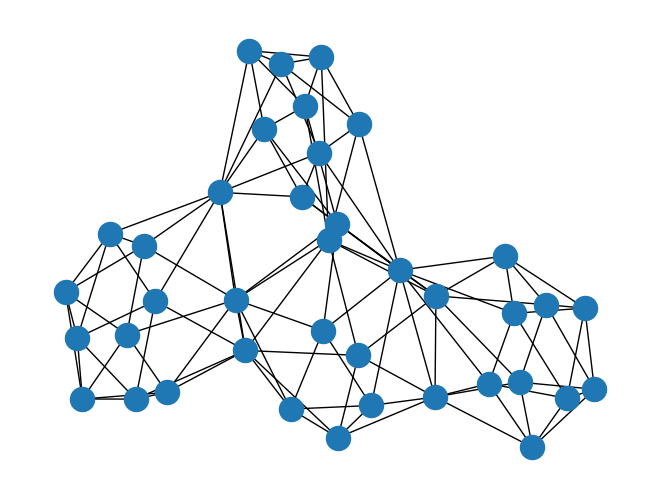

In [34]:
G2, G2_list = paste_graphs(icos1, icos2, [1,6,8], [3,4,10])
G3, G3_list = paste_graphs(G2, icos3, [16, 17, 8], [3,4,10])
G4, G4_list = paste_graphs(G3, icos4, [32, 33, 26], [3,4,10])
nx.draw(G4, pos=nx.spring_layout(G4, seed=6))

Now we bundle ```paste_graphs``` with ```random_planar_graph``` to allow us to quickly generate a bunch of random planar graphs and paste them together, along with copies of $W_8$ to get much more general $K_5$-minor-free graphs.

In [35]:
def build_maxK5minorfree_graph(part_sizes: list[int], parts_to_attach=None, verbose=False) -> tuple[nx.Graph, list[set]]:
    # this function is intended to generate examples to use as test cases for pack3_K5minorfree_corr()
    #
    # takes a list of nonnegative integers and generates a maximal K_5-minor-free graph where part i in the decomposition is a 
    # maximal planar graph of order list[i], or a copy of Wagner if list[i] == 0.  (If list[i] > 0, then we require list[i] >= 4.)
    # if parts_to_attach is provided, then we require that len(parts_to_attach) == len(part_sizes) - 1; otherwise, we do
    # parts_to_attach = list(range(len(part_sizes)-1))
    # now each part i will attach to part parts_to_attach[i-1] for i in range(1,len(part_sizes))
    # if both parts being attached are planar, then we pick a 3-face in each and identify those faces;
    # if one or both parts are Wagner, then we use *edges* instead of 3-faces.
    # ## TO ADD: finally, if we want, we can specify a vertex in the current part to identify with a vertex in the part we attach to

    def vprint(my_fstring):
        if verbose:
            print(my_fstring)
            
    wagner = nx.cycle_graph(8); wagner.add_edges_from({(i, i+4) for i in range(4)})
    is_wagner = {i:part_sizes[i]==0 for i in range(len(part_sizes))}
    if parts_to_attach is None:
        parts_to_attach = list(range(len(part_sizes)-1))
    else:
        assert len(parts_to_attach) == len(part_sizes) - 1
    
    if part_sizes[0] == 0:
        G = wagner.copy()
        G_list = [set(G)]

    else:
        assert part_sizes[0] > 3, "Each part must have at least 4 vertices."
        size = part_sizes[0]
        G = random_planar_graph(size, 0.0001, full = True, verbose=verbose)
        # if verbose:
        #     G = random_planar_graph(size, 0, full = True, verbose=True)
        # else:
        #     G = random_planar_graph(size, 0, full = True)
        G_list = [set(G)]

    for i in range(1,len(part_sizes)):
        size = part_sizes[i]
        attach_size = 3  # at least temporarily
        if is_wagner[i]:
            H = wagner.copy()
            H_list = [set(H)]
            attach_size = 2
        else:
            assert size > 3, "Each part must have at least 4 vertices."
            H = random_planar_graph(size, 0.0001, full = True, verbose=verbose)
            H_list = [set(H)]
            if is_wagner[parts_to_attach[i-1]]:
                attach_size = 2
        
        # get set_here, set_there  (first 2 elements in each)
        need_sets = True
        while need_sets:
            v_here = int(rng.choice(list(H)))
            w_here = int(rng.choice(list(H.neighbors(v_here))))
            v_there = int(rng.choice(list(G_list[parts_to_attach[i-1]])))
            v_there_nbrs = set(G.neighbors(v_there)) & G_list[parts_to_attach[i-1]]
            w_there = v_there_nbrs.pop()
            set_here = [v_here, w_here]
            set_there = [v_there, w_there]
            good_in_G = good_in_H = True
    
            if attach_size == 3:  # if needed, extend to 3rd elements
                x_here = (set(H.neighbors(v_here)) & set(H.neighbors(w_here))).pop()
                w_there_nbrs = set(G.neighbors(w_there)) & G_list[parts_to_attach[i-1]]
                x_there = (v_there_nbrs & w_there_nbrs).pop()
                set_here.append(x_here)
                set_there.append(x_there)
                good_in_G = nx.is_connected(nx.subgraph(G, G.nodes - set_there)) 
                good_in_H = nx.is_connected(nx.subgraph(H, H.nodes - set_here)) 
                vprint(f"Good in G: {good_in_G} and good in H: {good_in_H}.")
                vprint(f"set_here is {set_here} and set_there is {set_there}.")
            if  good_in_G and good_in_H:
                need_sets = False

        G, G_list = paste_graphs(G, H, set_there, set_here, G_list, H_list)

    
    # Now we check that the pieces have the desired properties
    verts_seen = set()
    for i in range(len(part_sizes)):
        if part_sizes[i] == 0:
            assert nx.is_isomorphic(nx.subgraph(G,G_list[i]), wagner)  # each piece induces W_8
        else:
            G_i = nx.subgraph(G,G_list[i])
            is_planar, embedding = nx.check_planarity(G_i)  # or is maximal planar
            assert len(G_list[i]) >= part_sizes[i] and is_planar and 3 * len(G_list[i]) - 6 == len(G_i.edges()) 
            # for simplicity of construction, we allow that len(G_list[i]) >= part_sizes[i] to allow adding verts inside 4^+-faces
        if i > 0:
            common_verts = G_list[i] & verts_seen
            if is_wagner[i] or is_wagner[parts_to_attach[i-1]]:
                assert len(common_verts) == 2  # intersection has size 2
            else:
                assert len(common_verts) == 3  # or intersection has size 3
                v1, v2, v3 = common_verts
                assert embedding.traverse_face(v1,v2)[2] == v3 or embedding.traverse_face(v2,v1)[2] == v3   # v1, v2, v3 is a face
            assert all(G.has_edge(x1,x2) for x1,x2 in combinations(common_verts, 2))  # intersection induces a clique
            assert common_verts <= G_list[parts_to_attach[i-1]]  # attaches as desired
        verts_seen |= G_list[i]
    assert verts_seen == set(G.nodes())  # every vertex of G is in at least one piece

    return G, G_list

In [36]:
G_homebrew, G_home_list = build_maxK5minorfree_graph([50, 80, 30, 0, 0, 18, 85, 60, 0, 43, 9, 0, 16, 25, 4, 17, 6, 0, 0, 0, 0, 9], verbose = True)

Added 1 extra vertices to reach a full triangulation.
Order of G is 51 and size of G is 147.
Added 1 extra vertices to reach a full triangulation.
Order of G is 81 and size of G is 237.
Good in G: True and good in H: True.
set_here is [35, 31, 41] and set_there is [31, 33, 43].
Added 1 extra vertices to reach a full triangulation.
Order of G is 31 and size of G is 87.
Good in G: True and good in H: True.
set_here is [23, 12, 25] and set_there is [76, 65, 114].
Added 1 extra vertices to reach a full triangulation.
Order of G is 19 and size of G is 51.
Added 1 extra vertices to reach a full triangulation.
Order of G is 86 and size of G is 252.
Good in G: True and good in H: True.
set_here is [66, 22, 58] and set_there is [4, 1, 43].
Added 1 extra vertices to reach a full triangulation.
Order of G is 61 and size of G is 177.
Good in G: True and good in H: True.
set_here is [25, 7, 21] and set_there is [71, 24, 31].
Added 2 extra vertices to reach a full triangulation.
Order of G is 45 and

In [37]:
G_small, G_small_list = build_maxK5minorfree_graph([0, 43, 9, 0, 16, 25, 4, 17, 6, 0, 0, 0, 0, 9], [0, 1, 2, 1, 0, 0, 1, 1, 6, 0, 9, 4, 1])

In [38]:
G_small_matchings = make_6matchings_random(G_small)
assert all(x in G_small for S in G_small_list for x in S)
small_packing = pack3_K5minorfree_corr(G_small,G_small_matchings, G_small_list)

In [39]:
G_home_matchings = make_6matchings_random(G_homebrew)
assert all(x in G_homebrew for S in G_home_list for x in S)
home_packing = pack3_K5minorfree_corr(G_homebrew,G_home_matchings, G_home_list, verbose = True)

Piece number 0 is planar.
Piece number 0 successfully colored.
Piece number 1 is planar.
Piece number 1 successfully colored.
Piece number 2 is planar.
Piece number 2 successfully colored.
Piece number 3 is Wagner.
Piece number 3 successfully colored.
Piece number 4 is Wagner.
Piece number 4 successfully colored.
Piece number 5 is planar.
Piece number 5 successfully colored.
Piece number 6 is planar.
Piece number 6 successfully colored.
Piece number 7 is planar.
Piece number 7 successfully colored.
Piece number 8 is Wagner.
Piece number 8 successfully colored.
Piece number 9 is planar.
Piece number 9 successfully colored.
Piece number 10 is planar.
Piece number 10 successfully colored.
Piece number 11 is Wagner.
Piece number 11 successfully colored.
Piece number 12 is planar.
Piece number 12 successfully colored.
Piece number 13 is planar.
Piece number 13 successfully colored.
Piece number 14 is planar.
Piece number 14 successfully colored.
Piece number 15 is planar.
Piece number 15 su